# 01 — Synthetic Data and the MNL Baseline

This notebook walks through the foundation of the project:

1. **Generate** a synthetic discrete-choice dataset with known true parameters.
2. **Fit** a plain Multinomial Logit (MNL) model to it.
3. **Observe** how MNL handles preference heterogeneity — and where it breaks.

The synthetic-data approach is the entire point. Because we *set* the
true betas, we can compare every estimate directly against ground truth.
That removes the usual ambiguity of "is the model right?" and replaces it
with the much sharper question: "did the estimator recover the truth?"

> **What you should take away by the end:** MNL produces sensible-looking
> coefficient estimates, but on the random-coefficient attributes those
> estimates are **biased toward zero**. That bias is the textbook signature
> of fitting MNL to data with preference heterogeneity, and it is precisely
> the problem Mixed Logit is designed to solve.


## 1. The synthetic choice experiment

We generate data from a stated-preference style choice experiment with:

- **500 individuals** (decision-makers)
- **8 choice situations** per individual (a panel structure)
- **3 alternatives** per choice situation
- **3 attributes** describing each alternative

The attributes are deliberately mixed across distribution types — this is
exactly the heterogeneity story we want to study:

| Attribute | True coefficient distribution | Interpretation |
|---|---|---|
| `price` | Normal, mean **−1.2**, sd **0.4** | Negative utility, varying price sensitivity |
| `quality` | Normal, mean **+0.8**, sd **0.5** | Positive utility, varying quality preference |
| `brand_known` | Fixed (homogeneous), value **+0.6** | Universal brand premium |

Two random coefficients, one fixed. That's the population we'll try to
recover.

In [1]:
from mixedlogit.dgp import default_config, simulate_choices

cfg = default_config()
df = simulate_choices(cfg)

print(f"Total rows:       {len(df):,}")
print(f"Choice situations: {df['situation_id'].nunique():,}")
print(f"Individuals:       {df['individual_id'].nunique():,}")
print(f"Alternatives/sit:  {df.groupby('situation_id').size().iloc[0]}")
print()
df.head(9)

Total rows:       12,000
Choice situations: 4,000
Individuals:       500
Alternatives/sit:  3



,individual_id,situation_id,alt_id,chosen,price,quality,brand_known
0,0,0,0,1,0.5,0.0,1.0
1,0,0,1,0,1.5,0.0,1.0
2,0,0,2,0,1.0,-1.0,1.0
3,0,1,0,0,1.0,-1.0,1.0
4,0,1,1,1,1.5,1.0,1.0
5,0,1,2,0,1.0,1.0,1.0
6,0,2,0,0,1.0,-1.0,1.0
7,0,2,1,1,1.0,1.0,0.0
8,0,2,2,0,1.0,-1.0,1.0


The data is in **long format**: one row per (individual, situation, alternative).
The `chosen` column flags which alternative the individual picked in each
situation.

Quick sanity check — exactly one alternative chosen per situation:

In [2]:
assert (df.groupby("situation_id")["chosen"].sum() == 1).all()
print("OK: every situation has exactly one chosen alternative.")

OK: every situation has exactly one chosen alternative.


## 2. Ground truth is visible even before fitting a model

A useful sanity check before estimation: the **chosen alternatives** should
have systematically different attribute values than the average alternative,
in the direction of the true coefficient signs.

If `price` has a negative coefficient, chosen alternatives should have
*lower* price than the population average. If `quality` has a positive
coefficient, chosen alternatives should have *higher* quality. If the
estimator is going to recover the right signs, this pattern needs to be
present in the raw data first.

In [3]:
import pandas as pd

chosen = df[df["chosen"] == 1]
all_alts = df

comparison = pd.DataFrame({
    "chosen alts (mean)":  chosen[["price", "quality", "brand_known"]].mean(),
    "all alts (mean)":     all_alts[["price", "quality", "brand_known"]].mean(),
})
comparison["difference"] = comparison["chosen alts (mean)"] - comparison["all alts (mean)"]
comparison.round(3)

,chosen alts (mean),all alts (mean),difference
price,1.057,1.243,-0.186
quality,0.262,0.002,0.261
brand_known,0.587,0.503,0.084


- `price`: chosen alternatives are **cheaper** on average — consistent with negative price coefficient.
- `quality`: chosen alternatives are **higher quality** — consistent with positive quality coefficient.
- `brand_known`: chosen alternatives are **more often branded** — consistent with positive brand coefficient.

All three signs match the true population betas. This pattern would have to
appear in real data too for any choice model to be identifiable.

## 3. Fit a plain MNL model

The Multinomial Logit (MNL) likelihood for a single choice situation is

$$
P(j \text{ chosen}) = \frac{\exp(\beta' x_j)}{\sum_{k} \exp(\beta' x_k)}
$$

with $\beta$ a single coefficient vector shared across the entire
population. That's the assumption we want to test against the truth.

The `fit_mnl` function uses BFGS with an analytical gradient and reports
McFadden's pseudo-$R^2$, asymptotic standard errors, and t-values.

In [4]:
from mixedlogit.mnl import fit_mnl

mnl = fit_mnl(df, attr_names=["price", "quality", "brand_known"])
print(mnl)

MNLResult(n_obs=4000, LL=-3596.461, LL0=-4394.449, R2=0.1816, converged=True)
               coef  std_err  t_value
price       -1.1138   0.0425 -26.2107
quality      0.7171   0.0285  25.1312
brand_known  0.6088   0.0437  13.9372


The estimator converged in a handful of iterations, every coefficient is
strongly significant ($|t| > 10$ across the board), and the pseudo-$R^2$ of
~0.18 is reasonable for choice models.

But significance is not the same as accuracy.

## 4. The attenuation bias

Now compare the MNL estimates side-by-side with the true population
parameters:

In [5]:
truth = {
    "price":       {"mean": -1.2, "sd": 0.4, "kind": "Normal"},
    "quality":     {"mean":  0.8, "sd": 0.5, "kind": "Normal"},
    "brand_known": {"mean":  0.6, "sd": 0.0, "kind": "Fixed"},
}

estimate = dict(zip(mnl.coef_names, mnl.coefficients, strict=True))
se       = dict(zip(mnl.coef_names, mnl.std_errors,  strict=True))

rows = []
for name in mnl.coef_names:
    rows.append({
        "attribute":             name,
        "true distribution":     truth[name]["kind"],
        "true mean":             truth[name]["mean"],
        "MNL estimate":          estimate[name],
        "MNL SE":                se[name],
        "deviation (in SEs)":    (estimate[name] - truth[name]["mean"]) / se[name],
    })

pd.DataFrame(rows).round(3)

,attribute,true distribution,true mean,MNL estimate,MNL SE,deviation (in SEs)
0,price,Normal,-1.2,-1.114,0.042,2.028
1,quality,Normal,0.8,0.717,0.029,-2.907
2,brand_known,Fixed,0.6,0.609,0.044,0.201


Read the deviation column carefully. For `brand_known` (the truly
homogeneous coefficient), the estimate is within ~0.2 SE of the true value.
That's textbook MNL behaviour: when the assumption holds, the estimate is
unbiased.

For the two random-coefficient attributes (`price` and `quality`), the
deviation is much larger — and crucially, the estimates are **closer to
zero** than the truth in both cases. This is the **attenuation bias from
omitted heterogeneity**: when you fit a homogeneous model to heterogeneous
data, the estimated population coefficient gets pulled toward zero.

Visualizing it:

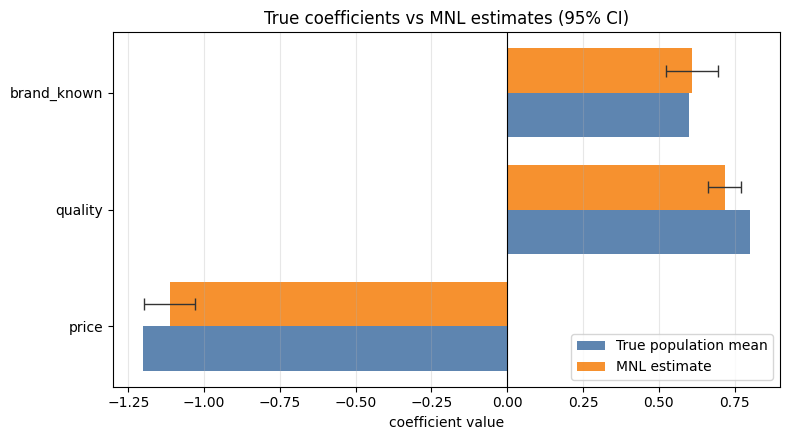

In [6]:
import matplotlib.pyplot as plt
import numpy as np

names = mnl.coef_names
true_vals = np.array([truth[n]["mean"] for n in names])
est_vals  = np.array([estimate[n] for n in names])
ses       = np.array([se[n] for n in names])

fig, ax = plt.subplots(figsize=(8, 4.5))
y = np.arange(len(names))
height = 0.38

ax.barh(y - height/2, true_vals,  height, label="True population mean",
        color="#4C78A8", alpha=0.9)
ax.barh(y + height/2, est_vals,   height, label="MNL estimate",
        color="#F58518", alpha=0.9, xerr=1.96 * ses, capsize=4,
        error_kw={"ecolor": "#333", "lw": 1})

ax.axvline(0, color="black", lw=0.8)
ax.set_yticks(y)
ax.set_yticklabels(names)
ax.set_xlabel("coefficient value")
ax.set_title("True coefficients vs MNL estimates (95% CI)")
ax.legend(loc="lower right")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

Look at the `price` and `quality` bars: the orange (estimate) is visibly
shorter than the blue (truth), in both directions toward zero. The
`brand_known` bars match almost exactly.

**This is the failure mode that motivates Mixed Logit.** The next notebook
fits MXL to the same data and shows that with a properly heterogeneous
specification, all three attributes — including the truly random ones — get
recovered correctly.

## What's next

- **Notebook 02** fits Mixed Logit on the same data, showing parameter
  recovery for both means *and* standard deviations.
- **Notebook 03** turns those estimates into elasticities and exposes the
  IIA failure of MNL via differentiated substitution patterns.
- **Notebook 04** computes WTP distributions and ranks features by
  population-level willingness-to-pay.

The key lesson from this notebook: **a model that converges, has a good
$R^2$, and produces highly significant estimates can still be biased**. The
gap between "fits well" and "estimates the truth" is the gap MXL closes.
